# Updates

> finish base & implement sigmoid, MSELoss, fully connect layer

> implement plot, ReLU, tanh, ELU, Adam , RMSprop

> implememt CNN layer

# Libraries

In [18]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# DataSet
generate two different dataset for training

>linear dataset

In [19]:
def generate_linear(n = 100):
    pts = np.random.uniform(0, 1, (n, 2))
    inputs = []
    labels = []
    
    for pt in pts:
        inputs.append([pt[0], pt[1]])
        distance = (pt[0] - pt[1])/1.414
        if pt[0] > pt[1]:
            labels.append(0)
        else:
            labels.append(1)
            
    return np.array(inputs), np.array(labels).reshape(n,1)

# output array(100, 2) , array(100, 1)

>XOR dataset

In [20]:
def generate_XOR_easy():
    inputs = []
    labels = []
    
    for i in range(11):
        inputs.append([0.1*i, 0.1*i])
        labels.append(0)
        
        if 0.1*i == 0.5:
            continue
        inputs.append([0.1*i, 1 - 0.1*i])
        labels.append(1)
    
    return np.array(inputs), np.array(labels).reshape(21,1)

# Activation Functions 

>sigmoid

In [22]:
def Sigmoid(x, derivative = False):
    if not derivative:
        return 1.0/ (1.0 + np.exp(- x))
    else:
        return x * (1 - x)

> ReLU

In [23]:
def ReLU(x, derivative = False):
    if not derivative:
        return np.where(x > 0, x, 0)
    else:
        return np.where(x > 0, 1, 0)

> tanh

In [24]:
def tanh(x, derivative = False):
    if not derivative:
        return np.tanh(x)
    else:
        return 1 - ( np.tanh(x)**2 )

> ELU

In [25]:
def ELU(x, alpha=1.0, derivative = False):
    if not derivative:
        return np.where(x <= 0, alpha * (np.exp(x) - 1), x)
    else:
        return np.where(x < 0, alpha * np.exp(x), 1)

# Loss Functions

>MSE

In [26]:
def MSELoss(y_true, y_pred, derivative = False):
    if not derivative:
        return np.mean((y_true - y_pred) ** 2)
    else:
        return 2 * (y_pred - y_true) / y_true.size


# Layers Structure

>fully connected layers

In [27]:
class FC_Layer:
    def __init__(self, input_dim, output_dim, activation = "Sigmoid", alpha = 0.1, init = "He"):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.activation = activation
        self.alpha = alpha
        self.init = init
        match self.init:
            case "rand":
                self.weight = np.random.randn(input_dim, output_dim) 
            case "He":
                self.weight = np.random.randn(input_dim, output_dim) * np.sqrt(2 / (self.input_dim))
            case "xavier":
                self.weight = np.random.randn(input_dim, output_dim) * np.sqrt(2 / (self.input_dim + self.output_dim))
        self.bias = np.zeros((1, self.output_dim))
        #bias init to zero
        self.A_prev = None
        self.Z = None
        self.A = None
        self.dW = None
        self.db = None
        self.dA_prev = None
        
    def forward(self, A_prev):
        self.A_prev = A_prev
        self.Z = np.dot(A_prev, self.weight) + self.bias      #Z is intermediate, Z = W^T * A + b
        
        
        match self.activation:
            #compute A with Z pass through activation function
            case "Sigmoid":
                self.A = Sigmoid(self.Z, derivative = False)
            case "ReLU":
                self.A = ReLU(self.Z, derivative = False)
            case "tanh":
                self.A = tanh(self.Z, derivative = False)
            case "ELU":
                self.A = ELU(self.Z, self.alpha, derivative = False)
            case _:
                #for no activation function
                self.A = self.Z
         
        return self.A
    
    def backward(self, dA):
        #dA is from prev layer of backward(next layer of forward)

        match self.activation:
            #compute dZ, where dZ is gradient of this layer
            case "Sigmoid":
                dZ = dA * Sigmoid(self.A, derivative = True)
            case "ReLU":
                dZ = dA * ReLU(self.A, derivative = True)
            case "tanh":
                dZ = dA * tanh(self.A, derivative = True)
            case "ELU":
                dZ = dA * ELU(self.A, self.alpha, derivative = True)
            case _:
                #for no activation function
                dZ = dA
        
        self.dW = np.dot(self.A_prev.T, dZ)
        #calculate dW by using dZ (store during forward pass)and A_prev (from forward pass)
        self.db = np.sum(dZ, axis = 0, keepdims = True) 
        #calculate db by using dZ only
        self.dA_prev = np.dot(dZ, self.weight.T)
        return self.dA_prev
        #dA_prev is dA of this layer, so pass it to next layer
            
            # more activation add here
    
    def update_parameters(self, lr, optim):
        match optim.name:
            case "SGD":         
                self.weight, self.bias = optim.update(lr, self.weight, self.bias, self.dW, self.db)
            case "Adam":
                self.weight, self.bias = optim.update(lr, self.weight, self.bias, self.dW, self.db)
            case "RMSprop":
                self.weight, self.bias = optim.update(lr, self.weight, self.bias, self.dW, self.db)
    
        

> 1D convolution

In [28]:
class Conv1d_Layer:
    def __init__(self, input_dim = 2, filter_size = 2, stride = 1, padding = 0, activation = "Sigmoid", alpha = 0.1, init = "He"):
        self.input_dim = input_dim
        self.filter_size = filter_size
        self.stride = stride
        self.padding = padding
        self.activation = activation
        self.alpha = alpha
        self.init = init
        match self.init:
            case "rand":
                self.filter = np.random.randn(self.filter_size) * 0.01
            case "He":
                self.filter = np.random.randn(self.filter_size) * np.sqrt(2 / np.sqrt(2 / (self.input_dim)))
            case "xavier":
                self.filter = np.random.randn(self.filter_size) * np.sqrt(2 / np.sqrt(2 / (self.input_dim + self.output_dim)))
        
        # He initilize
        #self.bias = np.random.randn(1)
        self.bias = np.zeros(1)
        
        # create filters and biases for CNN
        #bias just a scalar in this case
        self.A_prev = None
        self.A_prev_padded = None
        self.Z = None
        self.A = None
        self.dW = None
        self.db = None
        self.dA_prev = None
        # for forward pass and backward pass
        
    def forward(self, A_prev):
        self.A_prev = A_prev
        num_samples = A_prev.shape[0]
        # there may be 2D input if there are multiple layers
        output_length = (self.input_dim - self.filter_size + 2 * self.padding) // self.stride + 1
        #calculate output_length for this layer
        if self.padding > 0:
            #self.A_prev_padded = np.pad(self.A_prev, (self.padding, self.padding), mode='constant', constant_values=(1e-8, 1e-8))
            self.A_prev_padded = np.pad(self.A_prev, ((0, 0), (self.padding, self.padding)), mode='constant', constant_values=(0, 0))
        else:
            self.A_prev_padded = self.A_prev
        #apply padding 
        #np.pad(array, pad_width, mode='constant', **kwargs)
        
        self.Z = np.zeros((num_samples, output_length))

        for i in range(output_length):
            start = i * self.stride
            end = start + self.filter_size
            A_prev_slice = self.A_prev_padded[:, start:end]
            self.Z[:, i] = np.dot(A_prev_slice, self.filter) + self.bias
        
        
        match self.activation:
            #compute A with Z pass through activation function
            case "Sigmoid":
                self.A = Sigmoid(self.Z, derivative = False)
            case "ReLU":
                self.A = ReLU(self.Z, derivative = False)
            case "tanh":
                self.A = tanh(self.Z, derivative = False)
            case "ELU":
                self.A = ELU(self.Z, self.alpha, derivative = False)
            case _:
                #for no activation function
                self.A = self.Z
         
        return self.A
        
        
    
    def backward(self, dA):
        A_prev_shape = self.A_prev.shape[0]
        
        if self.activation == "Sigmoid":
            dZ = dA * Sigmoid(self.A, derivative=True)
        elif self.activation == "ReLU":
            dZ = dA * ReLU(self.A, derivative=True)
        elif self.activation == "tanh":
            dZ = dA * tanh(self.A, derivative=True)
        elif self.activation == "ELU":
            dZ = dA * ELU(self.A, self.alpha, derivative=True)
        else:
            dZ = dA
        
        num_samples = dZ.shape[0]
        self.dW = np.zeros_like(self.filter)
        self.db = np.sum(dZ)
        self.dA_prev_padded = np.zeros_like(self.A_prev_padded)
        
        output_length = self.Z.shape[1]

        for i in range(output_length):
            start = i * self.stride
            end = start + self.filter_size
            self.dW += np.sum(self.A_prev_padded[:, start:end] * dZ[:, i][:, np.newaxis], axis=0)
            self.dA_prev_padded[:, start:end] += dZ[:, i][:, np.newaxis] * self.filter
        
        if self.padding > 0:
            self.dA_prev = self.dA_prev_padded[:, self.padding:-self.padding]
        else:
            self.dA_prev = self.dA_prev_padded

        return self.dA_prev

    def update_parameters(self, lr, optim):
        match optim.name:
            case "SGD":         
                self.fliter, self.bias = optim.update(lr, self.filter, self.bias, self.dW, self.db)
            case "Adam":
                self.fliter, self.bias = optim.update(lr, self.filter, self.bias, self.dW, self.db)
            case "RMSprop":
                self.fliter, self.bias = optim.update(lr, self.filter, self.bias, self.dW, self.db)
        

# Optimizer

> SGD

In [29]:
class SGD_optimizer:
    def __init__(self):
        self.name = "SGD"
        
    def update(self, lr, W, b, dW, db):
        self.W = W
        self.b = b
        self.dW = dW
        self.db = db
        self.W -= lr * self.dW
        self.b -= lr * self.db
        return self.W , self.b
        

> Adam

In [30]:
class Adam_optimizer:
    def __init__(self, beta1 = 0.9, beta2 = 0.999, epsilon = 1e-8):
        self.name = "Adam"
        self.m_dW = 0
        self.m_db = 0
        self.v_dW = 0
        self.v_db = 0
        self.v_dW_hat = epsilon
        self.v_db_hat = epsilon
        self.beta1, self.beta2 = beta1, beta2
        self.epsilon = epsilon
        self.t = 1
        #initial t = 1
    
    def update(self, lr, W, b, dW, db):
        self.m_dW = self.beta1 * self.m_dW + (1 - self.beta1) * dW
        self.m_db = self.beta1 * self.m_db + (1 - self.beta1) * db
        # using beta1 to calculate Momentum
        self.v_dW = self.beta2 * self.v_dW + (1 - self.beta2) * (dW ** 2)
        self.v_db = self.beta2 * self.v_db + (1 - self.beta2) * db
        # using beta2 to calculate RMS
        
        m_dW_hat = self.m_dW / (1 - self.beta1 ** self.t)
        m_db_hat = self.m_db / (1 - self.beta1 ** self.t)
        self.v_dW_hat = np.maximum(self.v_dW / (1 - self.beta2 ** self.t), self.v_dW_hat)
        self.v_db_hat = np.maximum(self.v_db / (1 - self.beta2 ** self.t), self.v_db_hat)
        #new m, v according to time t
        
        self.W, self.b = W, b
        self.W -= lr * (m_dW_hat / (np.sqrt(self.v_dW_hat) + self.epsilon))
        self.b -= lr * (m_db_hat / (np.sqrt(self.v_db_hat) + self.epsilon))
        self.t += 1
        #update t
        
        return self.W, self.b
    

> RMSprop

In [31]:
class RMSprop_optimizer:
    def __init__(self, beta=0.9, epsilon=1e-8):
        self.name = "RMSprop"
        self.beta = beta
        self.epsilon = epsilon
        self.v_dW, self.v_db = epsilon, epsilon

    def update(self, lr, W, b, dW, db):
        self.v_dW = np.maximum(self.beta * self.v_dW + (1 - self.beta) * (dW ** 2), self.v_dW)
        self.v_db = np.maximum(self.beta * self.v_db + (1 - self.beta) * db, self.v_db)
            
        self.W, self.b = W, b
        self.W -= lr * (dW / (np.sqrt(self.v_dW) + self.epsilon))
        self.b -= lr * (db / (np.sqrt(self.v_db) + self.epsilon))
        return self.W, self.b 

# Hyperparameters
set some hyperparameters here!

In [32]:
output_epoch = 5000
alpha_for_ELU = 0.1


#for Conv1d
padding = 1
stride = 1
filter_size = 3

# Model

In [83]:
class Model:
    def __init__(self, optim, layer_type, input_dim = 2, hidden_layer_num = 2, hidden_dim = 4, 
                 output_dim = 1, lr = 0.01, activation = "Sigmoid", alpha = alpha_for_ELU, init = "He"):
        self.layers = []
        self.losses = []
        #collect every layers in order
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.hidden_layer_num = hidden_layer_num
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.activation = activation
        self.alpha = alpha
        self.optim = optim
        self.init = init
        
        if optim.name == "Adam":
            self.optims = []
            for i in range(self.hidden_layer_num + 2):
                self.optims.append(Adam_optimizer())
        elif optim.name == "RMSprop":
            self.optims = []
            for i in range(self.hidden_layer_num + 2):
                self.optims.append(RMSprop_optimizer())
                
        if layer_type == "FC":
            self.input_layer = FC_Layer(input_dim = self.input_dim, output_dim = self.hidden_dim, 
                                        activation = self.activation, alpha = self.alpha, init = self.init)
            self.output_layer = FC_Layer(input_dim = self.hidden_dim, output_dim = self.output_dim,
                                         activation = self.activation, alpha = self.alpha, init = self.init)
            self.layers.append(self.input_layer)
            for i in range(self.hidden_layer_num):
                self.layers.append(FC_Layer(input_dim = self.hidden_dim, output_dim = self.hidden_dim,
                                            activation = self.activation, alpha = self.alpha, init = self.init))
                
        elif layer_type == "Conv1d":
            #self.input_layer = Conv1d_Layer(input_dim = self.input_dim, filter_size = filter_size, stride = stride,
            #                                padding = padding, activation = self.activation, alpha = self.alpha)
            self.input_layer = FC_Layer(input_dim = self.input_dim, output_dim = self.hidden_dim,
                                        activation = self.activation, alpha = self.alpha, init = self.init)
            self.layers.append(self.input_layer)
            #out = (self.input_dim - filter_size + 2 * padding) // stride + 1
            out = self.hidden_dim 
            for i in range(self.hidden_layer_num):
                self.layers.append(Conv1d_Layer(input_dim = out, filter_size = filter_size, stride = stride, 
                                                padding = padding, activation = self.activation, alpha = self.alpha, init = self.init))
                out = (out - filter_size + 2 * padding) // stride + 1
                
            self.output_layer = FC_Layer(input_dim = out, output_dim = self.output_dim, 
                                         activation = self.activation, alpha = self.alpha, init = self.init)
        self.layers.append(self.output_layer)

    
        
    def forward(self, X):
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A
    
    def backward(self, y_true):
        layers_num = len(self.layers)
        y_pred = self.layers[-1].A
        #prediction is equal to A in the last layer
        
        dA = MSELoss(y_true, y_pred, derivative = True)
        #apply derivative MSELoss
        grad = 0
        for i in reversed(range(layers_num)):
        # backward so in reverse order
            dA = self.layers[i].backward(dA)
            grad += np.mean(self.layers[i].dW)
            #update dA and pass it to prev layer
        #print(f"gradient in layer {i} = {grad}")
    def update_parameters(self, lr):
        for i, layer in enumerate(self.layers):
            if self.optim.name == "Adam":
                layer.update_parameters(lr,self.optims[i])
            elif self.optim.name == "RMSprop":
                layer.update_parameters(lr,self.optims[i])
            else:
                layer.update_parameters(lr, self.optim)
    
    def train(self, X, Y, epochs = 100000):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = MSELoss(Y, y_pred, derivative = False)
            self.losses.append(loss)
            #calculate loss with MSELoss
            self.backward(Y)
            #using loss to compute gradient for each layer from backward
        
            self.update_parameters(self.lr)
            #gradient descent
        
            if (epoch)% output_epoch == 0:
                print(f"epoch {epoch: <5} loss : {loss:<8.9f}")

    def show_result(self, x, y, pred_y):
        for i in range(y.size):
            print(f"Iter{i + 1:< 4} | Ground truth: {y[i].item()} | Prediction: {pred_y[i].item():<8.9f}")
        
        loss = np.sum(MSELoss(y, pred_y, derivative = False))
        
        count = 0
        
        for i in range(y.size):
            if (pred_y[i] >= 0.5 and y[i] == 1) or (pred_y[i] < 0.5 and y[i] == 0):
                count += 1
        accuracy = 100 * count / y.size
        print(f"loss = {loss} accuracy = {accuracy}%")
        
        # for printing output
        plt.subplot(2,1,1)
        plt.subplots_adjust(hspace=0.5) 
        plt.title("Learning Curve", fontsize = 18)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.plot(self.losses)
        # for plotting losses
        plt.subplot(2,2,3, aspect='equal')
        plt.title('Ground truth', fontsize=18)
        for i in range(x.shape[0]):
            if y[i] == 0:
                plt.plot(x[i][0], x[i][1], 'ro')
            else:
                plt.plot(x[i][0], x[i][1], 'bo')
            
        plt.subplot(2,2,4, aspect='equal')
        
        plt.title('Predict result', fontsize=18)
        for i in range(x.shape[0]):
            if pred_y[i] < 0.5:
                plt.plot(x[i][0], x[i][1], 'ro')
            else:
                plt.plot(x[i][0], x[i][1], 'bo')
        
        plt.show()
        # for plotting result
        
    def predict(self, X):
        return self.forward(X)
        
        
        
        

# Main

In [34]:
np.random.seed(340)
# set random seed
x1, y1 = generate_linear(n = 100)
x2, y2 = generate_XOR_easy()
# generate two dataset for training

> 3A,3B,3C

Linear

In [ ]:
optimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "Sigmoid", lr = 0.1)
model.train(x1, y1, epochs = 100000)
predictions = model.predict(x1)

model.show_result(x1, y1, predictions)

XOR

In [ ]:
optimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "Sigmoid", lr = 0.1)
model.train(x2, y2, epochs = 100000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)

> 4A

different lr
> 0.01

In [ ]:
optimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "Sigmoid", lr = 0.01)
model.train(x1, y1, epochs = 100000)
predictions = model.predict(x1)

model.show_result(x1, y1, predictions)

> lr = 1

In [ ]:
optimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "Sigmoid", lr = 1)
model.train(x1, y1, epochs = 100000)
predictions = model.predict(x1)

model.show_result(x1, y1, predictions)

In [ ]:
optimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "Sigmoid", lr = 0.01)
model.train(x2, y2, epochs = 200000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)

In [ ]:
optimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "Sigmoid", lr = 1)
model.train(x2, y2, epochs = 100000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)

 4B.Try different hidden dim
> dim = 2

In [ ]:
optimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 2,
              activation = "Sigmoid", lr = 0.1)
model.train(x1, y1, epochs = 100000)
predictions = model.predict(x1)

model.show_result(x1, y1, predictions)

epoch 0     loss : 0.275275289
epoch 5000  loss : 0.249608661
epoch 10000 loss : 0.249510328
epoch 15000 loss : 0.249460055
epoch 20000 loss : 0.249425535
epoch 25000 loss : 0.249392085
epoch 30000 loss : 0.249348515
epoch 35000 loss : 0.249278881
epoch 40000 loss : 0.249147772
epoch 45000 loss : 0.248846397
epoch 50000 loss : 0.247871745
epoch 55000 loss : 0.241666740
epoch 60000 loss : 0.216064388
epoch 65000 loss : 0.200093074
epoch 70000 loss : 0.068910022
epoch 75000 loss : 0.045770078
epoch 80000 loss : 0.044022632
epoch 85000 loss : 0.043659402
epoch 90000 loss : 0.043524618
epoch 95000 loss : 0.043458107
Iter 1   | Ground truth: 0 | Prediction: 0.002067283
Iter 2   | Ground truth: 1 | Prediction: 0.906656046
Iter 3   | Ground truth: 0 | Prediction: 0.002109689
Iter 4   | Ground truth: 1 | Prediction: 0.906656046
Iter 5   | Ground truth: 0 | Prediction: 0.002242569
Iter 6   | Ground truth: 1 | Prediction: 0.906656046
Iter 7   | Ground truth: 0 | Prediction: 0.002944214
Iter 8   

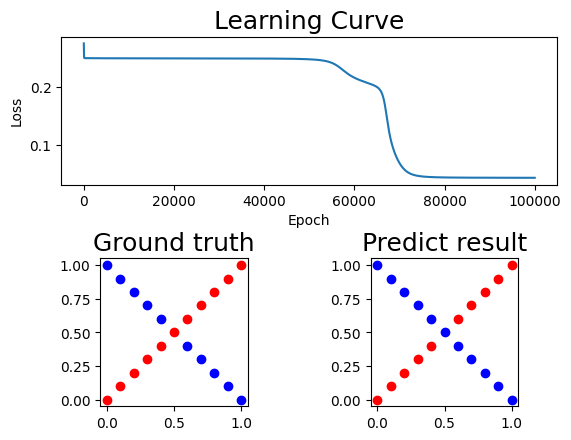

In [25]:
optimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 2,
              activation = "Sigmoid", lr = 0.1)
model.train(x2, y2, epochs = 100000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)

> dim = 16

In [ ]:
optimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 16,
              activation = "Sigmoid", lr = 0.1)
model.train(x1, y1, epochs = 100000)
predictions = model.predict(x1)

model.show_result(x1, y1, predictions)

epoch 0     loss : 0.297944275
epoch 5000  loss : 0.249190024
epoch 10000 loss : 0.248830868
epoch 15000 loss : 0.247562796
epoch 20000 loss : 0.237237005
epoch 25000 loss : 0.052271619
epoch 30000 loss : 0.012755621
epoch 35000 loss : 0.003133343
epoch 40000 loss : 0.001306487
epoch 45000 loss : 0.000737282
epoch 50000 loss : 0.000487640
epoch 55000 loss : 0.000354125
epoch 60000 loss : 0.000273217
epoch 65000 loss : 0.000219846
epoch 70000 loss : 0.000182425
epoch 75000 loss : 0.000154955
epoch 80000 loss : 0.000134059
epoch 85000 loss : 0.000117704
epoch 90000 loss : 0.000104603
epoch 95000 loss : 0.000093904
Iter 1   | Ground truth: 0 | Prediction: 0.000013822
Iter 2   | Ground truth: 1 | Prediction: 0.999997944
Iter 3   | Ground truth: 0 | Prediction: 0.000033438
Iter 4   | Ground truth: 1 | Prediction: 0.999997968
Iter 5   | Ground truth: 0 | Prediction: 0.000194840
Iter 6   | Ground truth: 1 | Prediction: 0.999997471
Iter 7   | Ground truth: 0 | Prediction: 0.001981099
Iter 8   

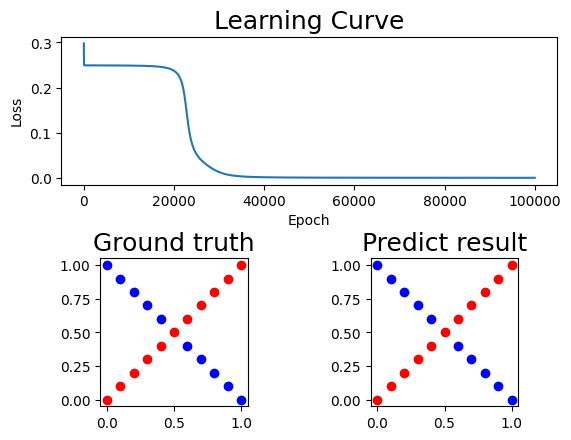

In [26]:
opimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 16,
              activation = "Sigmoid", lr = 0.1)
model.train(x2, y2, epochs = 100000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)

 4C.Try without activation functions


In [ ]:
optimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "None", lr = 0.03)
model.train(x1, y1, epochs = 100000)
predictions = model.predict(x1)

model.show_result(x1, y1, predictions)

In [ ]:
optimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "None", lr = 0.1)
model.train(x2, y2, epochs = 100000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)

> 4D

epoch 0     loss : 0.329987858
epoch 5000  loss : 0.239801889
epoch 10000 loss : 0.238720514
epoch 15000 loss : 0.238443112
epoch 20000 loss : 0.238326572
epoch 25000 loss : 0.238264758
epoch 30000 loss : 0.238227219
epoch 35000 loss : 0.238202318
epoch 40000 loss : 0.238184743
epoch 45000 loss : 0.238171756
epoch 50000 loss : 0.238161813
epoch 55000 loss : 0.238153985
epoch 60000 loss : 0.238147680
epoch 65000 loss : 0.238142504
epoch 70000 loss : 0.238138188
epoch 75000 loss : 0.238134539
epoch 80000 loss : 0.238131419
epoch 85000 loss : 0.238128723
epoch 90000 loss : 0.238126372
epoch 95000 loss : 0.238124307
Iter 1   | Ground truth: 0 | Prediction: 0.006129019
Iter 2   | Ground truth: 1 | Prediction: 0.000000000
Iter 3   | Ground truth: 0 | Prediction: 0.005906787
Iter 4   | Ground truth: 1 | Prediction: 0.000000000
Iter 5   | Ground truth: 0 | Prediction: 0.005692566
Iter 6   | Ground truth: 1 | Prediction: 0.000000000
Iter 7   | Ground truth: 0 | Prediction: 0.005486072
Iter 8   

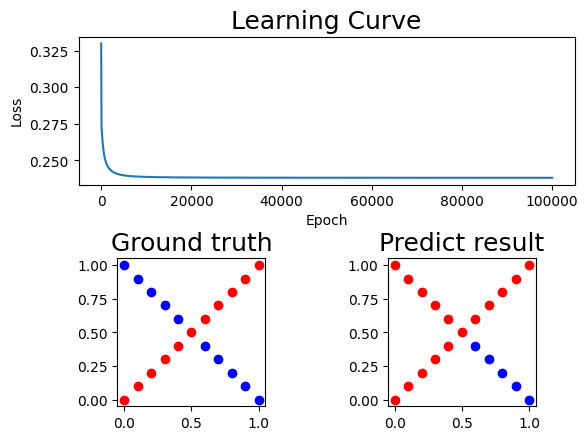

In [91]:
opimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 10, output_dim = 1, hidden_dim = 10,
              activation = "None", lr = 0.0003)
model.train(x2, y2, epochs = 100000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)

epoch 0     loss : 0.280045365
epoch 5000  loss : 0.204776890
epoch 10000 loss : 0.090782805
epoch 15000 loss : 0.055442540
epoch 20000 loss : 0.037199285
epoch 25000 loss : 0.024233510
epoch 30000 loss : 0.015793436
epoch 35000 loss : 0.010726816
epoch 40000 loss : 0.007684849
epoch 45000 loss : 0.005782190
epoch 50000 loss : 0.004530697
epoch 55000 loss : 0.003667583
epoch 60000 loss : 0.003047352
epoch 65000 loss : 0.002585907
epoch 70000 loss : 0.002232430
epoch 75000 loss : 0.001954914
epoch 80000 loss : 0.001732440
epoch 85000 loss : 0.001550876
epoch 90000 loss : 0.001400401
epoch 95000 loss : 0.001274013
Iter 1   | Ground truth: 0 | Prediction: 0.032436634
Iter 2   | Ground truth: 1 | Prediction: 0.999239906
Iter 3   | Ground truth: 0 | Prediction: 0.032388857
Iter 4   | Ground truth: 1 | Prediction: 0.999237819
Iter 5   | Ground truth: 0 | Prediction: 0.032341165
Iter 6   | Ground truth: 1 | Prediction: 0.999209421
Iter 7   | Ground truth: 0 | Prediction: 0.032293555
Iter 8   

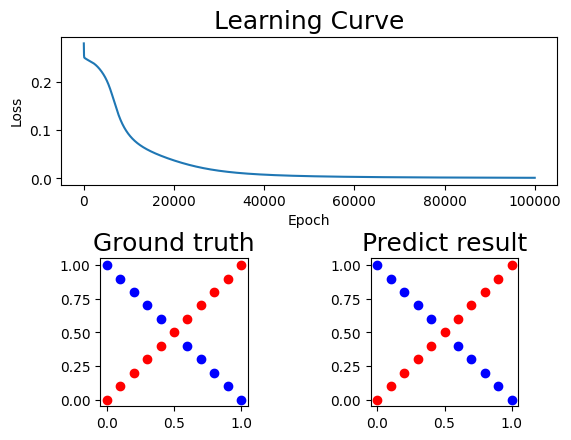

In [75]:
opimizer = SGD_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 0, output_dim = 1, hidden_dim = 2,
              activation = "Sigmoid", lr = 0.1)
model.train(x2, y2, epochs = 100000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)

5A.  Implement different optimizers

In [ ]:
optimizer = RMSprop_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "Sigmoid", lr = 0.01)
model.train(x1, y1, epochs = 100000)
predictions = model.predict(x1)

model.show_result(x1, y1, predictions)

In [ ]:
optimizer = RMSprop_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "Sigmoid", lr = 0.01)
model.train(x2, y2, epochs = 100000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)

In [ ]:
optimizer = Adam_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "Sigmoid", lr = 0.01)
model.train(x1, y1, epochs = 100000)
predictions = model.predict(x1)

model.show_result(x1, y1, predictions)

In [ ]:
optimizer = Adam_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "Sigmoid", lr = 0.01)
model.train(x2, y2, epochs = 100000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)

5B. Implement different activation functions

ReLU

In [ ]:
optimizer = Adam_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "ReLU", lr = 0.0003)
model.train(x1, y1, epochs = 100000)
predictions = model.predict(x1)

model.show_result(x1, y1, predictions)

In [ ]:
optimizer = Adam_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "ReLU", lr = 0.0003)
model.train(x2, y2, epochs = 100000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)

tanh

In [ ]:
optimizer = Adam_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "tanh", lr = 0.0004)
model.train(x1, y1, epochs = 100000)
predictions = model.predict(x1)

model.show_result(x1, y1, predictions)

In [ ]:
optimizer = Adam_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "tanh", lr = 0.001)
model.train(x2, y2, epochs = 100000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)

ELU

In [ ]:
optimizer = Adam_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "ELU", lr = 0.0003)
model.train(x1, y1, epochs = 100000)
predictions = model.predict(x1)

model.show_result(x1, y1, predictions)

In [ ]:
optimizer = Adam_optimizer()
model = Model(optimizer, "FC", input_dim = 2, hidden_layer_num = 2, output_dim = 1, hidden_dim = 4,
              activation = "ELU", lr = 0.0001)
model.train(x2, y2, epochs = 100000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)

5C
> Conv_1d

In [ ]:
optimizer = Adam_optimizer()
model = Model(optimizer, "Conv1d", input_dim = 2, hidden_layer_num = 4, output_dim = 1, hidden_dim = 4,
              activation = "Sigmoid", lr = 0.02)
model.train(x1, y1, epochs = 100000)

predictions = model.predict(x1)

model.show_result(x1, y1, predictions)

In [ ]:
optimizer = Adam_optimizer()
model = Model(optimizer, "Conv1d", input_dim = 2, hidden_layer_num = 4, output_dim = 1, hidden_dim = 4,
              activation = "ELU", lr = 0.001)
model.train(x2, y2, epochs = 100000)
predictions = model.predict(x2)

model.show_result(x2, y2, predictions)
